### StandardScaler Formula

The formula for Standard Scaler (Z-score normalization) is:

$$z = \frac{x - \mu}{\sigma}$$

Where:
*   **$z$**: Scaled value
*   **$x$**: Original value
*   **$\mu$**: Mean of the feature
*   **$\sigma$**: Standard deviation of the feature


In [1]:
import pandas as pd 
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [2]:
data = pd.read_csv('heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
X = data.drop('target',axis=1)
y = data['target']

In [67]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=69
)

In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [70]:
print("Explained Variance Ratio :",pca.explained_variance_ratio_)

Explained Variance Ratio : [0.19212937 0.11346173 0.1114142  0.08859075 0.07898974]


In [71]:
model = LogisticRegression()
model.fit(X_train_pca,y_train)

y_pred = model.predict(X_test_pca)

In [79]:
print("\nAccuracy :",accuracy_score(y_test,y_pred))
print("\nConfusion Matrix :",confusion_matrix(y_test,y_pred))
print("\nClassification Report :\n\n",classification_report(y_test,y_pred))


Accuracy : 0.7857142857142857

Confusion Matrix : [[142  57]
 [ 24 155]]

Classification Report :

               precision    recall  f1-score   support

           0       0.86      0.71      0.78       199
           1       0.73      0.87      0.79       179

    accuracy                           0.79       378
   macro avg       0.79      0.79      0.79       378
weighted avg       0.80      0.79      0.79       378



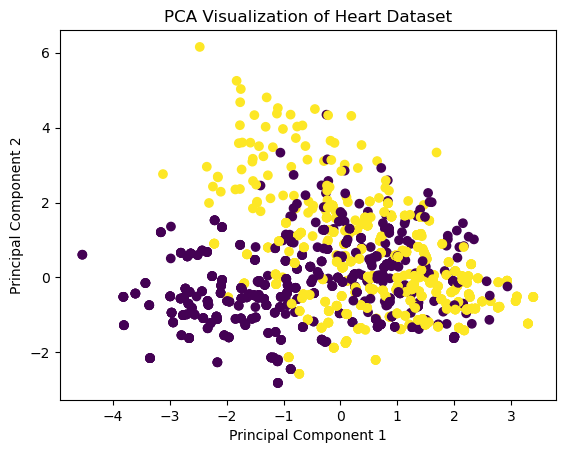

In [80]:
import matplotlib.pyplot as plt 

pca_2d = PCA(n_components=2)
x_pca_2d = pca_2d.fit_transform(X_train_scaled)
plt.scatter(x_pca_2d[:,0],x_pca_2d[:,1],c=y_train)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Heart Dataset")
plt.show()

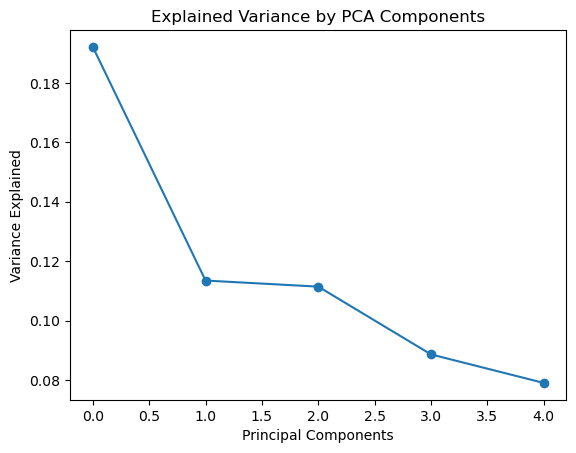

In [81]:
plt.plot(pca.explained_variance_ratio_,marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("Explained Variance by PCA Components")
plt.show()

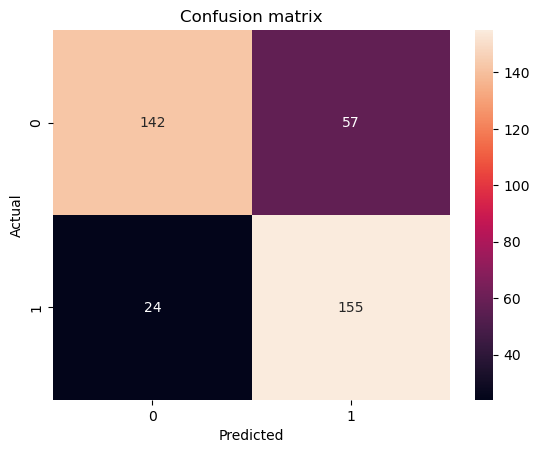

In [83]:
import seaborn as sns

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()